In [3]:
import pandas as pd
from matplotlib import pyplot as plt
from matplotlib.axes import Axes
import matplotlib.dates as mdates

In [6]:
data = pd.read_csv('../data_processed/SG_nona.csv')
data['date'] = pd.to_datetime(data['date'])
# df.drop((""), axis=1, inplace=True)
print(data.columns)

Index(['date', 'new_confirmed', 'new_deceased', 'new_tested',
       'cumulative_confirmed', 'cumulative_deceased', 'new_persons_vaccinated',
       'cumulative_persons_vaccinated', 'new_persons_fully_vaccinated',
       'cumulative_persons_fully_vaccinated',
       ...
       'search_trends_wheeze', 'search_trends_xeroderma',
       'search_trends_xerostomia', 'search_trends_yawn',
       'average_temperature_celsius', 'minimum_temperature_celsius',
       'maximum_temperature_celsius', 'rainfall_mm', 'dew_point',
       'relative_humidity'],
      dtype='str', length=502)


In [23]:
def configure_axis(ax: Axes, df_name) -> None:

    ax.xaxis.set_major_locator(mdates.MonthLocator(interval=3))
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d'))
    ax.set_xlim(min(df_name["date"]), max(df_name["date"]))

    ax.tick_params(axis='x', labelrotation=45, labelsize = 7)
    ax.tick_params(axis='x', labelrotation=45, labelsize = 7)

    ax.grid(True)


def simple_static_stats_plot(df,columns, titles, y_labels, colors, figname=None):
    fig, axs = plt.subplots(2,1,figsize = (9,7))

    dates_range = (df['date'].min(), df['date'].max())
    for column_nr in range(len(columns)):
        ax = axs[column_nr]
        ax.set_title(f"{titles[column_nr]} from {dates_range[0].date()} to {dates_range[1].date()}",)
        ax.plot(df['date'], df[columns[column_nr]],color = colors[column_nr])
        ax.set_ylabel(y_labels[column_nr])
        ax.set_xlabel('Date')
        configure_axis(ax=axs[column_nr],df_name=df)

    fig.tight_layout()
    plt.show()
    if figname is not None:
        fig.savefig(figname)

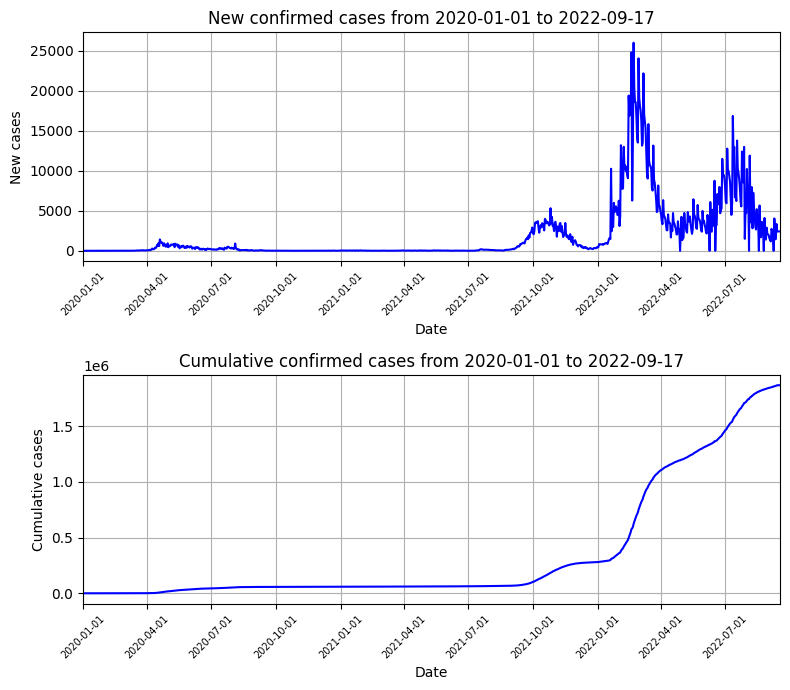

In [24]:
simple_static_stats_plot(data,
                              columns=("new_confirmed","cumulative_confirmed"),
                              titles=("New confirmed cases", "Cumulative confirmed cases"),
                              y_labels=("New cases", "Cumulative cases"),
                              colors=("blue","blue"),
                              figname="Cases"
                              )

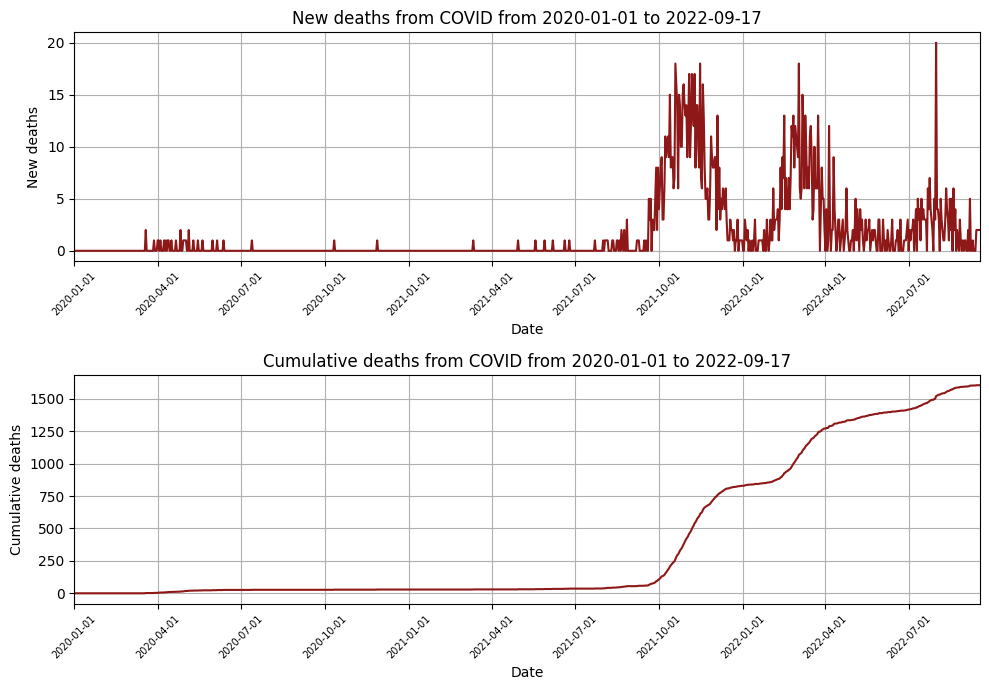

In [22]:
simple_static_stats_plot(data,
                              columns=("new_deceased","cumulative_deceased"),
                              titles=("New deaths from COVID", "Cumulative deaths from COVID"),
                              y_labels=("New deaths", "Cumulative deaths"),
                              colors=("#8E1717","#8E1717"),
                              figname="Deaths"
                              )

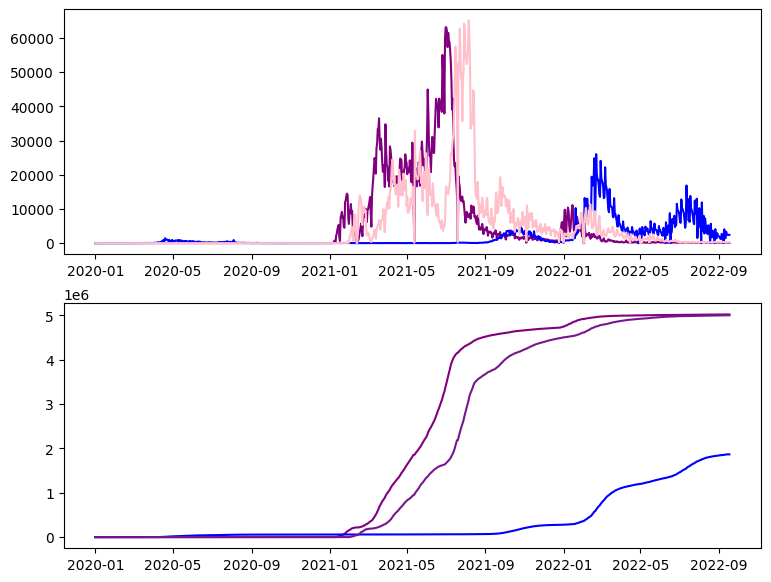

In [10]:
def vaccination_plot(df):
    fig, axs = plt.subplots(2,1,figsize = (9,7))

    axs[0].plot(df['date'], df['new_persons_vaccinated'], color = 'purple')
    axs[0].plot(df['date'], df["new_confirmed"], color = 'blue')
    axs[0].plot(df['date'], df['new_persons_fully_vaccinated'], color = 'pink')

    axs[1].plot(df['date'], df['cumulative_persons_vaccinated'], color = 'purple')
    axs[1].plot(df['date'], df["cumulative_confirmed"], color = 'blue')
    axs[1].plot(df['date'], df['cumulative_persons_fully_vaccinated'], color = '#76178E')

vaccination_plot(data)

In [14]:
import pandas as pd
from matplotlib import pyplot as plt
from matplotlib.axes import Axes
import matplotlib.dates as mdates

def configure_axis(ax: Axes, df_name: pd.DataFrame) -> None:
    """Configures the X-axis for date formatting and grid."""
    ax.xaxis.set_major_locator(mdates.MonthLocator(interval=3))
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d'))
    ax.set_xlim(min(df_name["date"]), max(df_name["date"]))

    ax.tick_params(axis='x', labelrotation=45, labelsize=7)
    ax.grid(True)

def simple_descriptive_plots(df: pd.DataFrame, figname: str = None) -> None:
    """
    Creates a dashboard with two subplots (daily and cumulative).
    Uses dual Y-axes to separate large numbers (cases/vaccines) from small numbers (deaths).
    Calculates 7-day rolling average for daily data.
    """
    # Create 2 subplots, one above the other
    fig, axs = plt.subplots(2, 1, figsize=(12, 10))

    # Define colors for consistency across subplots
    c_conf = 'blue'
    c_vacc = 'purple'
    c_full = 'pink'
    c_dec = '#8E1717'

    # ==========================================
    # 1. DAILY DYNAMICS (Top Subplot)
    # ==========================================
    ax1_left = axs[0]
    ax1_right = ax1_left.twinx() # Create second Y-axis

    ax1_left.set_title("Daily Dynamics: Cases, Vaccinations, and Deaths")
    ax1_left.set_ylabel("Cases / Vaccinations")
    ax1_right.set_ylabel("Deaths", color=c_dec)

    # Left Axis: Scatter (raw) + Line (7-day rolling average)
    for col, color, label in [
        ('new_confirmed', c_conf, 'New Confirmed'),
        ('new_persons_vaccinated', c_vacc, 'New Vaccinated'),
        ('new_persons_fully_vaccinated', c_full, 'New Fully Vacc.')
    ]:
        ax1_left.scatter(df['date'], df[col], color=color, alpha=0.2, s=10, shape = ".",label=f"{label} (raw)")
        ax1_left.plot(df['date'], df[col].rolling(7).mean(), color=color, alpha=1.0, linewidth=2, label=f"{label} (7d avg)")

    # Right Axis: Deaths
    ax1_right.scatter(df['date'], df['new_deceased'], color=c_dec, alpha=0.3, s=15, label="New Deaths (raw)")
    ax1_right.plot(df['date'], df['new_deceased'].rolling(7).mean(), color=c_dec, alpha=1.0, linewidth=2, label="New Deaths (7d avg)")

    configure_axis(ax1_left, df)

    # Legends placed OUTSIDE the plot area
    ax1_left.legend(loc='upper left', bbox_to_anchor=(1.05, 1), title="Left Axis (Cases/Vacc)")
    ax1_right.legend(loc='upper left', bbox_to_anchor=(1.05, 0.4), title="Right Axis (Deaths)")

    # ==========================================
    # 2. CUMULATIVE TOTALS (Bottom Subplot)
    # ==========================================
    ax2_left = axs[1]
    ax2_right = ax2_left.twinx() # Create second Y-axis

    ax2_left.set_title("Cumulative Totals: Cases, Vaccinations, and Deaths")
    ax2_left.set_ylabel("Total Cases / Vaccinations")
    ax2_right.set_ylabel("Total Deaths", color=c_dec)
    ax2_left.set_xlabel('Date')

    # Left Axis: Cumulative Lines only
    ax2_left.plot(df['date'], df['cumulative_confirmed'], color=c_conf, linewidth=2, label='Cum. Confirmed')
    ax2_left.plot(df['date'], df['cumulative_persons_vaccinated'], color=c_vacc, linewidth=2, label='Cum. Vaccinated')
    ax2_left.plot(df['date'], df['cumulative_persons_fully_vaccinated'], color=c_full, linewidth=2, label='Cum. Fully Vacc.')

    # Right Axis: Cumulative Deaths Line only
    ax2_right.plot(df['date'], df['cumulative_deceased'], color=c_dec, linewidth=2, label='Cum. Deaths')

    configure_axis(ax2_left, df)

    # Legends placed OUTSIDE the plot area
    ax2_left.legend(loc='upper left', bbox_to_anchor=(1.05, 1), title="Left Axis (Cases/Vacc)")
    ax2_right.legend(loc='upper left', bbox_to_anchor=(1.05, 0.4), title="Right Axis (Deaths)")

    # Adjust layout to make room for external legends
    fig.tight_layout()
    plt.show()

    # Save figure if name is provided (bbox_inches='tight' prevents legend clipping)
    if figname is not None:
        fig.savefig(figname, bbox_inches='tight')

# Использование функции:
# data = pd.read_csv('../data_processed/SG_nona.csv')
# data['date'] = pd.to_datetime(data['date'])
# simple_descriptive_plots(data, figname="Singapore_COVID_Summary.png")

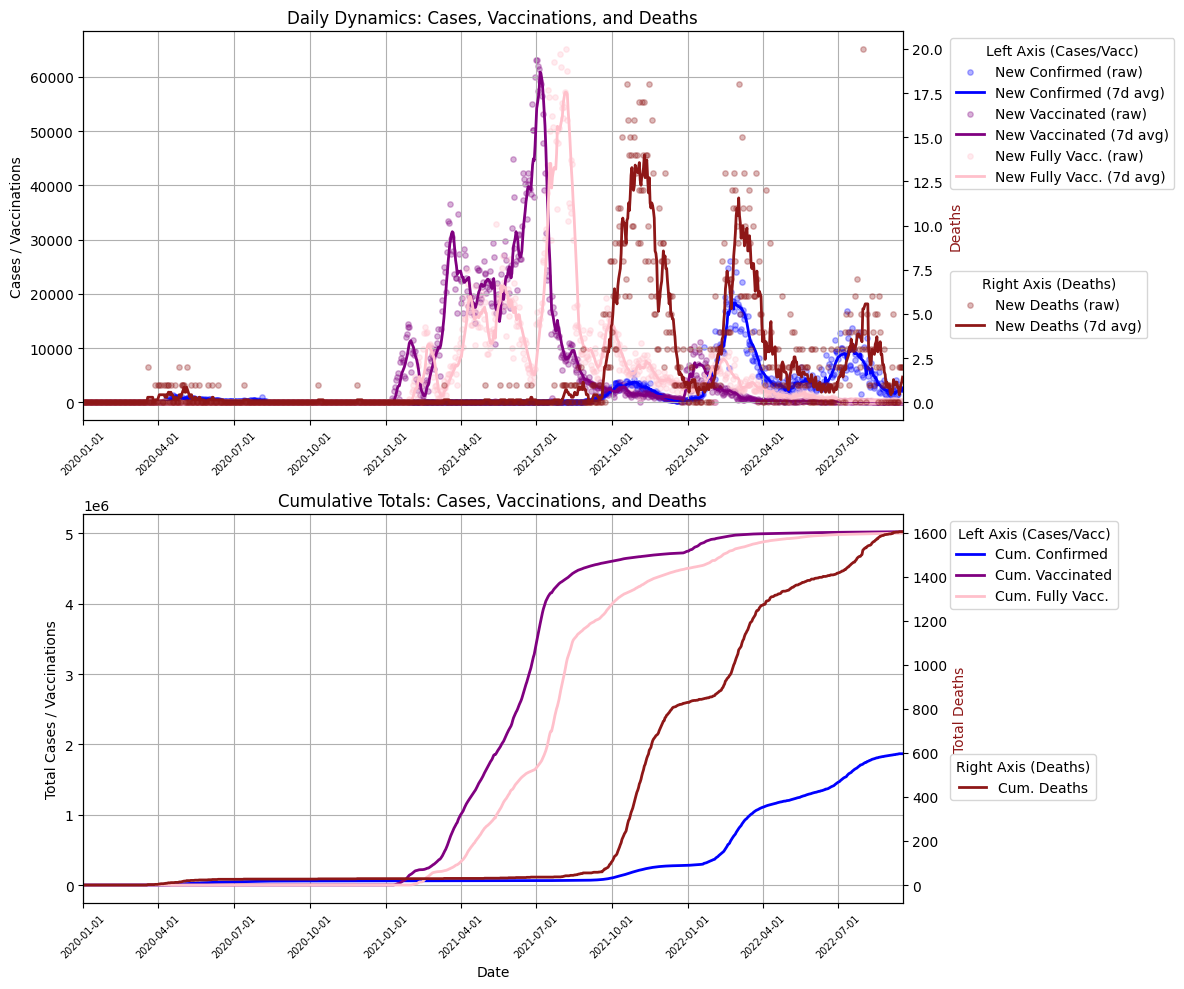

In [12]:
simple_descriptive_plots(data, figname="Singapore_COVID_Summary.png")